# Trader Performance vs Market Sentiment
### Analyzing how Bitcoin Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid

## Part A — Data Preparation

### Step 1: Import Libraries

In [1]:
#Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Datasets

In [2]:
fgi = pd.read_csv('fear_greed_index.csv')#The contains Bitcoin Market Sentiment (Fear/Greed)
fgi.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
hd = pd.read_csv('historical_data.csv')# This contains Historical Trader Data (Hyperliquid)
hd.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Explore Columns

In [4]:
#Let's see the columns. To understand how these features work together.
print('These are the columns of fear_greed_index\n', fgi.columns)
print('These are the columns of historical_data\n', hd.columns)

These are the columns of fear_greed_index
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
These are the columns of historical_data
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


### Shape, Missing Values & Duplicates

In [5]:
#Now, let's check the dataset's
print(fgi.shape) #This defines the shape of Bitcoin Market segment
print(hd.shape)  #This defines the shape of the historical data

#Checking for any null values

print(fgi.isnull().sum()) 
print(hd.isnull().sum())

#Checking for any duplicate's.
print("\nFear/Greed duplicates:", fgi.duplicated().sum())
print("Trades duplicates:", hd.duplicated().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear/Greed duplicates: 0
Trades duplicates: 0


### Data Types

In [6]:
#Let's see what kind of data we are working with Qualitative or Quantitative data.

print('\nThe datatypes for the Fear/Greed is:', fgi.dtypes)
print('\nThe datatype for the Trades is:', hd.dtypes)


The datatypes for the Fear/Greed is: timestamp          int64
value              int64
classification    object
date              object
dtype: object

The datatype for the Trades is: Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


### Fix Timestamps and align datasets

In [7]:
# Fix dates
fgi['date'] = pd.to_datetime(fgi['date'])
hd['Timestamp IST'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True)

# Extract just the date part from hd (we need daily level for merging)
hd['date'] = hd['Timestamp IST'].dt.date
hd['date'] = pd.to_datetime(hd['date'])


print("Fear/Greed date range:", fgi['date'].min(), "to", fgi['date'].max())
print("hd date range:", hd['date'].min(), "to", hd['date'].max())

Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
hd date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00


### Merge Datasets

In [8]:
# Merge on date (inner join keeps only overlapping dates)
merged = pd.merge(hd, fgi[['date', 'value', 'classification']], on='date', how='inner')

# Verify
print("Merged shape:", merged.shape)
print("Sentiment distribution:\n", merged['classification'].value_counts())

Merged shape: (211218, 19)
Sentiment distribution:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


### Part B - Analysis 

## Sentiment Distribution of Trades

| Sentiment      | Number of Trades | Observation                                      |
|----------------|-----------------|--------------------------------------------------|
| Fear           | 61,837          | Most active — traders buying dips or panic selling |
| Greed          | 50,303          | Active — riding the bullish momentum             |
| Extreme Greed  | 39,992          | FOMO driven activity                             |
| Neutral        | 37,686          | Low activity — uncertainty leads to inaction     |
| Extreme Fear   | 21,400          | Least active — extreme panic causes paralysis    |

> **Key Insight:** Trader activity is sentiment-driven. Moderate signals (Fear/Greed) trigger 
> the most action, while Extreme Fear causes behavioral paralysis — traders freeze instead of act.

## Understanding the Metrics

Before diving into the analysis, here's what each metric means in the context of crypto trading:

- **Average PnL (Profit and Loss):** The average amount of money a trader made or lost on a given day. 
A positive value means profit, negative means loss.

- **Average Win Rate:** The percentage of trades that were profitable. 
For example, a win rate of 0.36 means 36 out of 100 trades closed in profit.

- **Average Number of Trades:** How many trades a trader executed on a given day. 
Higher number = more active trading behavior.

- **Average Trade Size (USD):** The average dollar value of each trade placed. 
Larger size = bigger bets on market direction.

- **Long Ratio:** The proportion of trades that were "Buy" (long) positions — betting the price goes UP. 
A low long ratio means traders are predominantly **shorting** (betting price goes DOWN).
> Example: A long ratio of 0.09 means only 9% of trades were long — 91% were short positions.

In [ ]:
# Daily Metrics per trader
daily = merged.groupby(['date', 'Account', 'classification']).agg(
    pnl = ('Closed PnL', 'sum'),
    avg_trade = ('Size USD', 'mean'),
    num_trades = ('Trade ID', 'count'),
    total_fee = ('Fee', 'sum')
).reset_index()

# Win rate

merged['is_win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby(['date', 'Account'])['is_win'].mean().reset_index()
win_rate.columns = ['date', 'Account', 'win_rate']

#Ratio's

merged['is_long'] = merged['Direction'] == 'Buy'
Is_ratio = merged.groupby(['date', 'Account'])['is_long'].mean().reset_index()
Is_ratio_columns = ['date', 'Account', 'long_ratio']

daily = daily.merge(win_rate, on=['date', 'Account'])
daily = daily.merge(Is_ratio, on=['date', 'Account'])

print(daily.shape)
daily.head()

(2340, 9)


,date,Account,classification,pnl,avg_trade,num_trades,total_fee,win_rate,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,159.000000,3,0.000000,0.000000,0.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,5556.203333,9,12.501455,0.000000,0.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,10291.213636,11,28.300831,0.363636,0.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,5304.975000,2,2.652489,0.000000,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,5116.256667,3,3.837189,0.000000,0.0


### Performance by Sentiment

Here we are grouping by sentiment classification to answer

**Does a trader performance differ from while Being in Fear VS Greed days?**

In [10]:
sa = daily.groupby('classification').agg(
    avg_pnl = ('pnl', 'mean'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_trades = ('num_trades', 'mean'),
    avg_trade_size = ('avg_trade', 'mean'),
    avg_long_ratio = ('is_long', 'mean')
).reset_index()

print(sa)

  classification      avg_pnl  avg_win_rate  avg_trades  avg_trade_size  \
0   Extreme Fear  4619.439053      0.329659  133.750000     6773.464125   
1  Extreme Greed  5161.922644      0.386387   76.030418     5371.637182   
2           Fear  5328.818161      0.364033   98.153968     8975.928546   
3          Greed  3318.100730      0.343559   77.628086     6427.866594   
4        Neutral  3438.618818      0.355414  100.228723     6963.694861   

   avg_long_ratio  
0        0.070457  
1        0.137664  
2        0.089772  
3        0.104131  
4        0.103135  


### Charts

**Visualizing Performance by Sentiment**

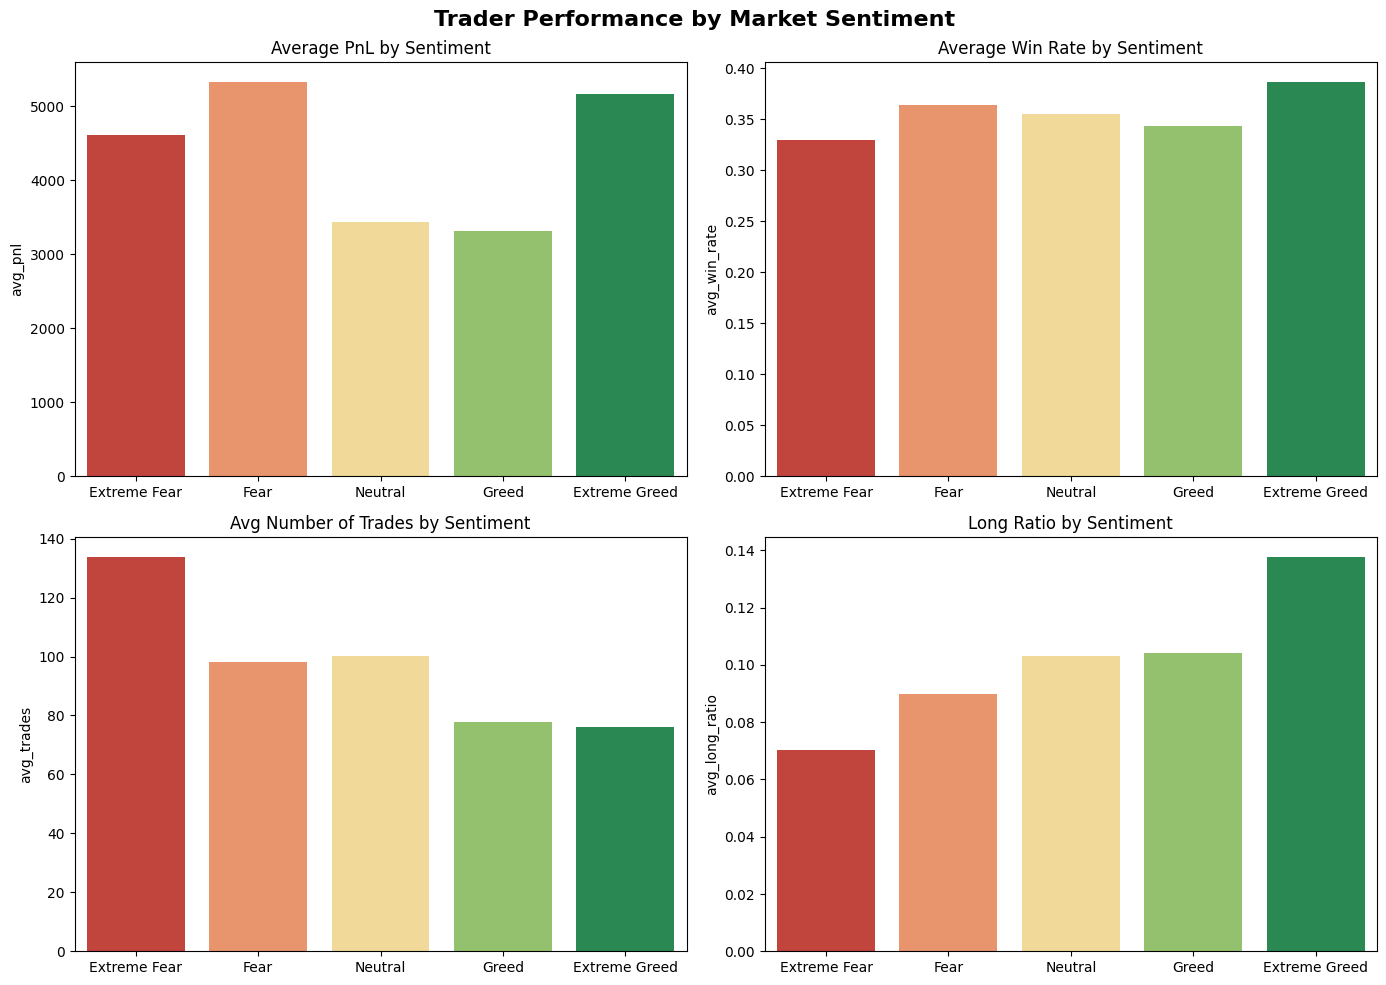

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=16, fontweight='bold')
# Define manual colors from red to green
palette = {
    'Extreme Fear': '#d73027',
    'Fear': '#fc8d59',
    'Neutral': '#fee08b',
    'Greed': '#91cf60',
    'Extreme Greed': '#1a9850'
}
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# PnL
sns.barplot(data=sa, x='classification', y='avg_pnl', order=order, ax=axes[0,0], hue='classification' ,palette=palette, legend=False)
axes[0,0].set_title('Average PnL by Sentiment')
axes[0,0].set_xlabel('')

# Win Rate
sns.barplot(data=sa, x='classification', y='avg_win_rate', order=order, ax=axes[0,1], hue='classification' ,palette=palette, legend=False)
axes[0,1].set_title('Average Win Rate by Sentiment')
axes[0,1].set_xlabel('')

# Trade Frequency
sns.barplot(data=sa, x='classification', y='avg_trades', order=order, ax=axes[1,0], hue='classification' ,palette=palette, legend=False)
axes[1,0].set_title('Avg Number of Trades by Sentiment')
axes[1,0].set_xlabel('')

# Long Ratio
sns.barplot(data=sa, x='classification', y='avg_long_ratio', order=order, ax=axes[1,1], hue='classification' ,palette=palette, legend=False)
axes[1,1].set_title('Long Ratio by Sentiment')
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.savefig('sentiment_performance.png', dpi=150, bbox_inches='tight')
plt.show()

### Trader Segmentation
We are segmenting the trader into 3 groups:

**Frequent vs Infrequent** - The average no of traders per day.

**Consistent Winners vs Inconsistent Winners** - The average of win rate.

**High vs Low Trade Size** - The average trade size(in $).

> Note: Leverage data was not directly avaliable in the dataset.

In [12]:
traders_profile = daily.groupby('Account').agg(
    total_pnl = ('pnl', 'sum'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_trades = ('num_trades', 'mean'),
    avg_trade_size = ('avg_trade', 'mean'),
    total_days = ('date', 'count')
).reset_index()

traders_profile['freq_segment'] = pd.qcut(traders_profile['avg_trades'], q=2, labels = ['Infrequent','Frequent'])

traders_profile['winner_segment'] = pd.qcut(traders_profile['avg_win_rate'], q=2, labels=['Inconsistent', 'Consistent Winner'])

traders_profile['size_segment'] = pd.qcut(traders_profile['avg_trade_size'], q=2, labels=['Low Size', 'High Size'])

print(traders_profile.shape)
traders_profile.head()

(32, 9)


,Account,total_pnl,avg_win_rate,avg_trades,avg_trade_size,total_days,freq_segment,winner_segment,size_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.352333,159.083333,33569.102224,24,Frequent,Consistent Winner,High Size
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.397134,140.000000,4359.830930,52,Frequent,Consistent Winner,Low Size
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.379952,317.416667,11057.118419,12,Frequent,Consistent Winner,High Size
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.452509,82.166667,484.844294,162,Frequent,Consistent Winner,Low Size
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.498708,46.942029,2553.757037,69,Infrequent,Consistent Winner,Low Size


### Visualizing the segments

C:\Temp\ipykernel_30300\1944019172.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_pnl = traders_profile.groupby('freq_segment')['total_pnl'].mean().reset_index()
C:\Temp\ipykernel_30300\1944019172.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  winner_pnl = traders_profile.groupby('winner_segment')['total_pnl'].mean().reset_index()
C:\Temp\ipykernel_30300\1944019172.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

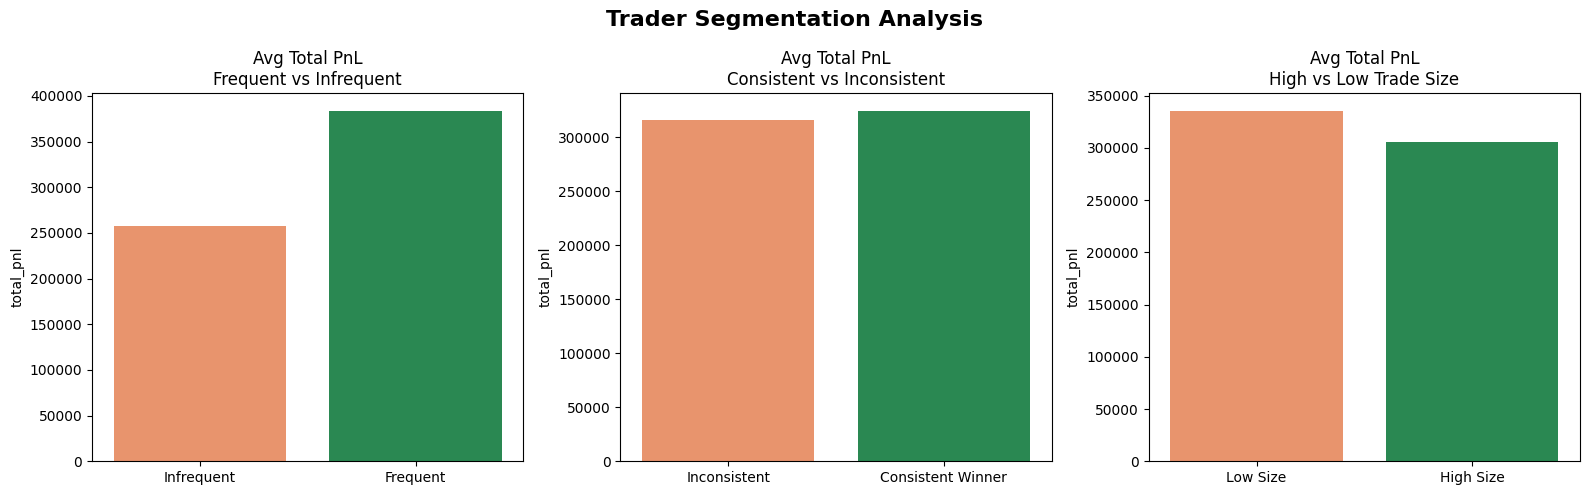

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Segmentation Analysis', fontsize=16, fontweight='bold')

# Segment 1: Frequent vs Infrequent - PnL comparison
freq_pnl = traders_profile.groupby('freq_segment')['total_pnl'].mean().reset_index()
sns.barplot(data=freq_pnl, x='freq_segment', y='total_pnl', 
            hue='freq_segment', palette={'Infrequent': '#fc8d59', 'Frequent': '#1a9850'}, 
            ax=axes[0], legend=False)
axes[0].set_title('Avg Total PnL\nFrequent vs Infrequent')
axes[0].set_xlabel('')

# Segment 2: Winners vs Inconsistent - PnL comparison
winner_pnl = traders_profile.groupby('winner_segment')['total_pnl'].mean().reset_index()
sns.barplot(data=winner_pnl, x='winner_segment', y='total_pnl',
            hue='winner_segment', palette={'Inconsistent': '#fc8d59', 'Consistent Winner': '#1a9850'},
            ax=axes[1], legend=False)
axes[1].set_title('Avg Total PnL\nConsistent vs Inconsistent')
axes[1].set_xlabel('')

# Segment 3: High vs Low trade size - PnL comparison
size_pnl = traders_profile.groupby('size_segment')['total_pnl'].mean().reset_index()
sns.barplot(data=size_pnl, x='size_segment', y='total_pnl',
            hue='size_segment', palette={'Low Size': '#fc8d59', 'High Size': '#1a9850'},
            ax=axes[2], legend=False)
axes[2].set_title('Avg Total PnL\nHigh vs Low Trade Size')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C — Actionable Strategy Recommendations

### Fear and Greed is an Opportunity

**Fear**
- **When** the market is about to crash, use fear as a driver to increase trading frequency.
- **Why** The one who stays calm and keeps trading during fear has the most profit — compared to the one who panics and stops.

**Greed**
- **When** the market is slow or nothing interesting is happening, have the hunger to win.
- **Why** It gives you time to learn, observe, and understand what may happen next — so you are ready when the opportunity comes.

---

### Consistency vs Inconsistency

No matter how consistent you are — an inconsistent trader who recognizes the quality of a trade will have the most profit.

Fear and sometimes Greed will become your backup.

Focus on being **selective and cautious**, not just active. Being extreme — whether in Greed or Fear — will become your biggest enemy.

> **Rule of Thumb:** Trade more during Fear, trade smarter during Greed, and stay out during Extreme Fear.